In [1]:
# YULU business case study
# YULU is a electric bike service provider, its seeking recommendations and advice on identifying
# factors that drive the demand of shared electric cycles.
# In this case study, Hypothesis testing will be used to understand these factors

In [3]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [5]:
# Read the dataset
df = pd.read_csv("yulu_data.csv")
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [9]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [11]:
# Duplicate values
df.duplicated().sum()

0

In [19]:
# Convert datetime column to datetime
df["datetime"] = pd.to_datetime(df["datetime"])

# Get date range
print("Min", df["datetime"].min())
print("Max", df["datetime"].max())

Min 2011-01-01 00:00:00
Max 2012-12-19 23:00:00


In [15]:
# Convert categorical columns
categorical_columns = ["season", "holiday", "workingday", "weather"]
for col in categorical_columns:
    df[col] = df[col].astype("category")

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  category      
 2   holiday     10886 non-null  category      
 3   workingday  10886 non-null  category      
 4   weather     10886 non-null  category      
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: category(4), datetime64[ns](1), float64(3), int64(4)
memory usage: 723.7 KB


In [25]:
# EDA - Exploratory data analysis
# Categorical columns
for col in categorical_columns:
    print(df[col].value_counts())

season
season
4    2734
2    2733
3    2733
1    2686
Name: count, dtype: int64
holiday
holiday
0    10575
1      311
Name: count, dtype: int64
workingday
workingday
1    7412
0    3474
Name: count, dtype: int64
weather
weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64


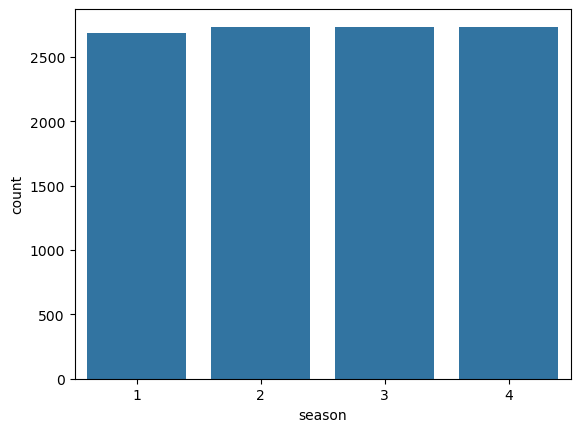

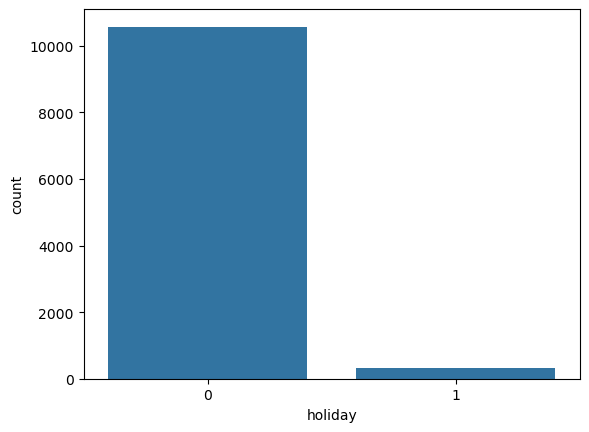

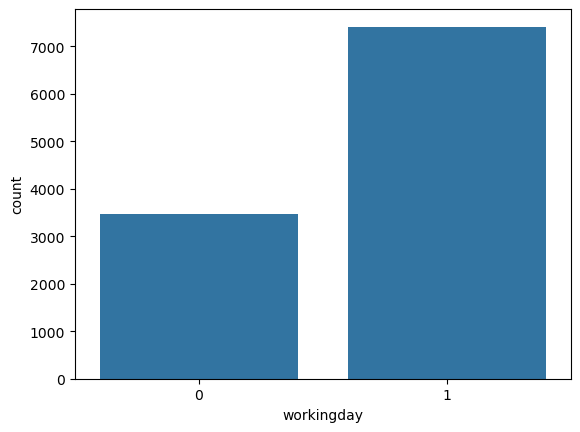

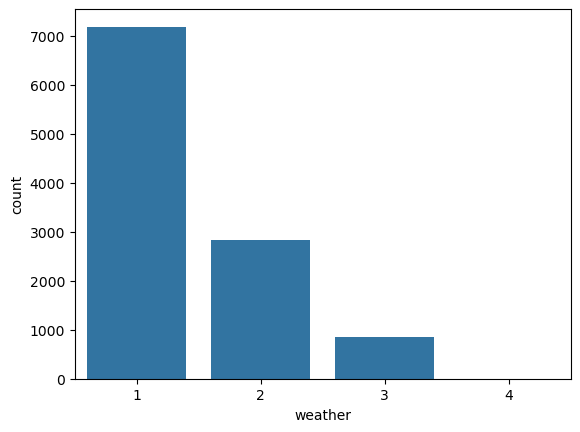

In [27]:
# Create countplots
for col in categorical_columns:
    sns.countplot(x=col, data=df)
    plt.show()

In [29]:
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

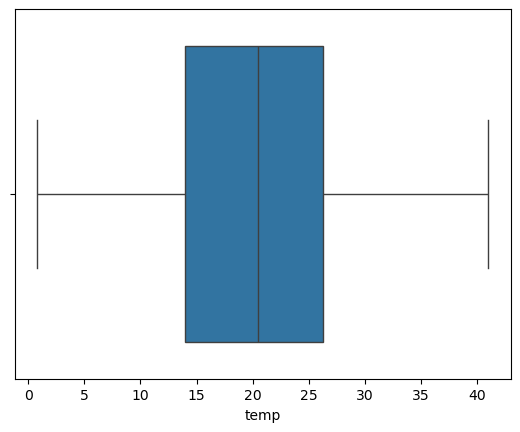

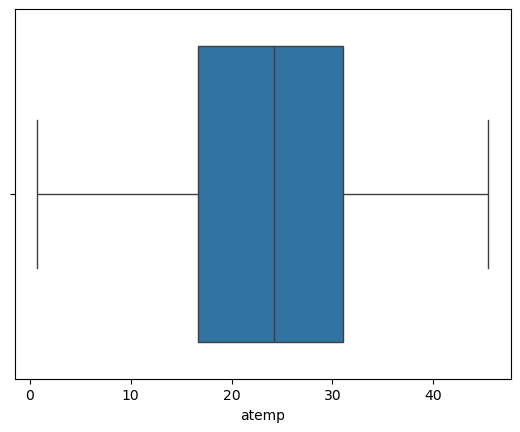

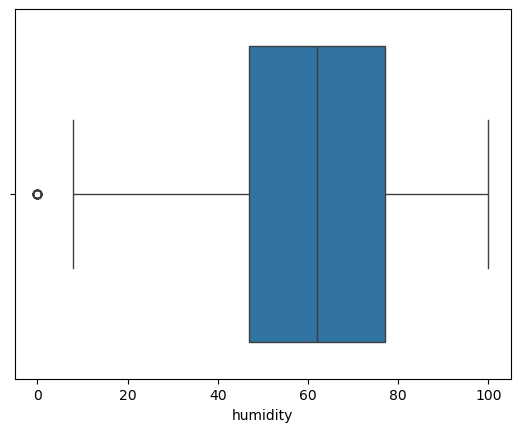

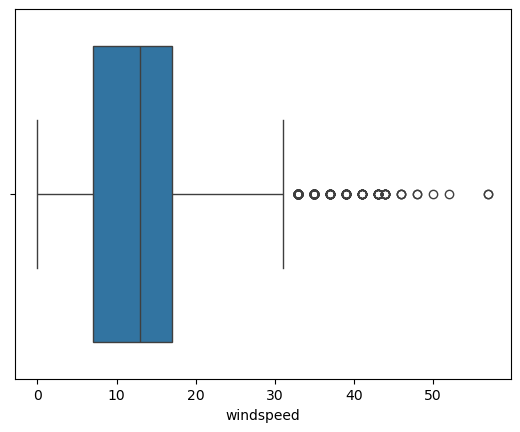

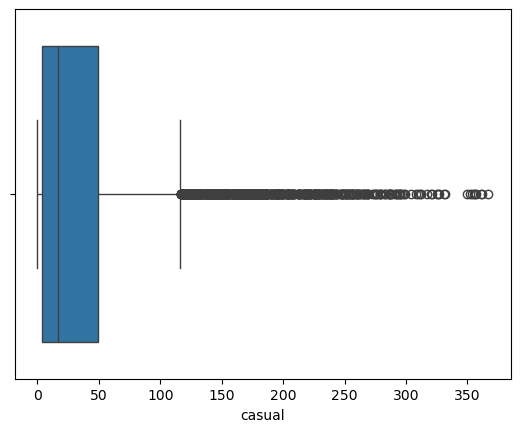

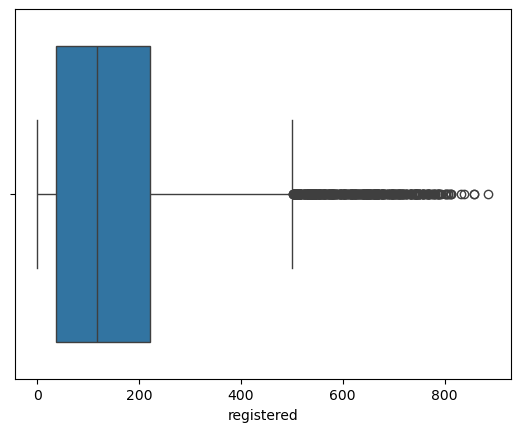

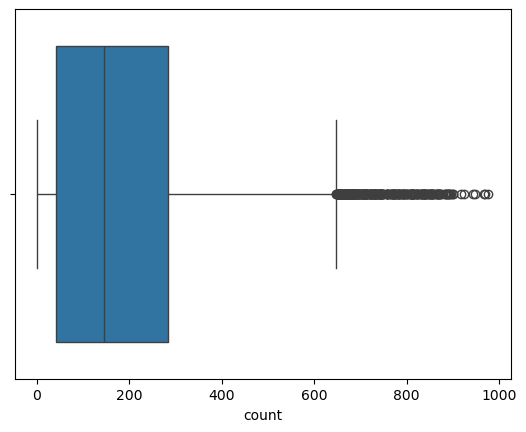

In [33]:
# Numerical columns
numerical_columns = ["temp", "atemp", "humidity", "windspeed", "casual", "registered", "count"]
for col in numerical_columns:
    sns.boxplot(x=col, data=df)
    plt.show()

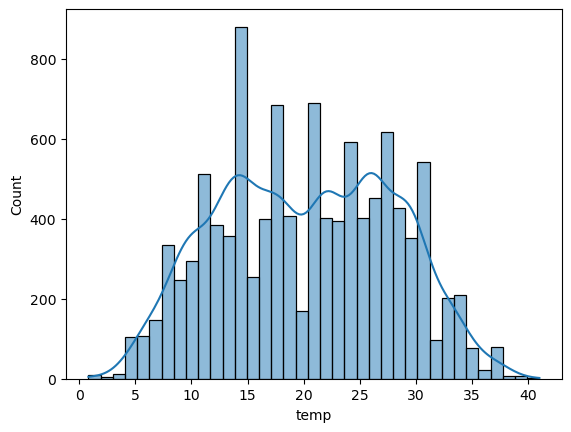

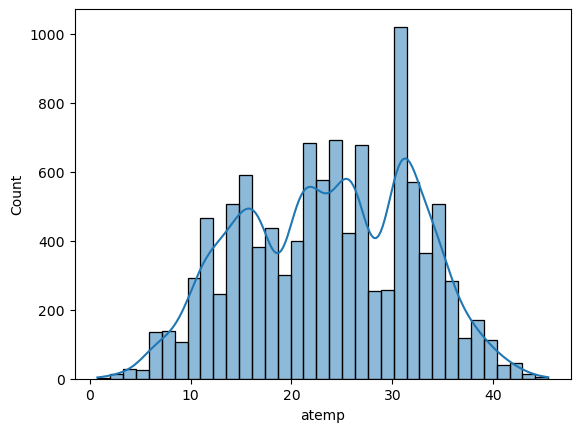

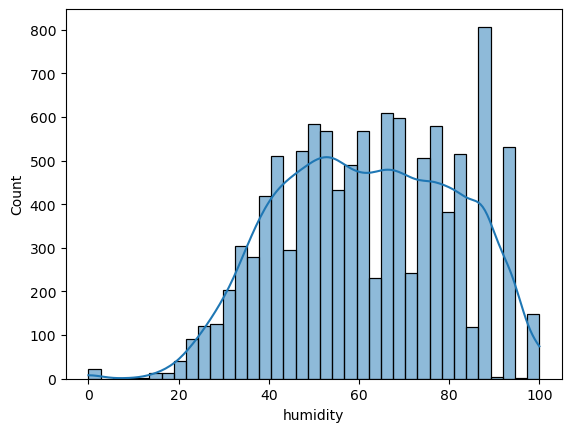

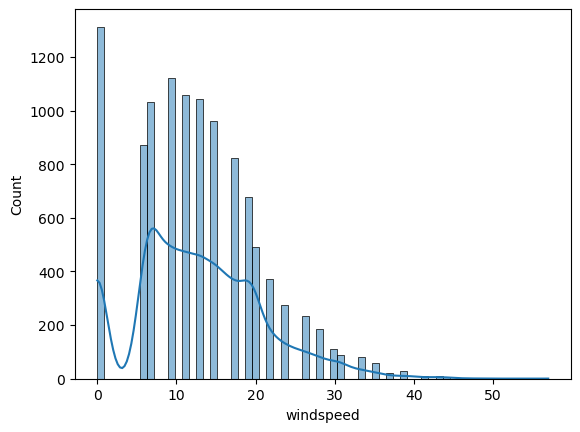

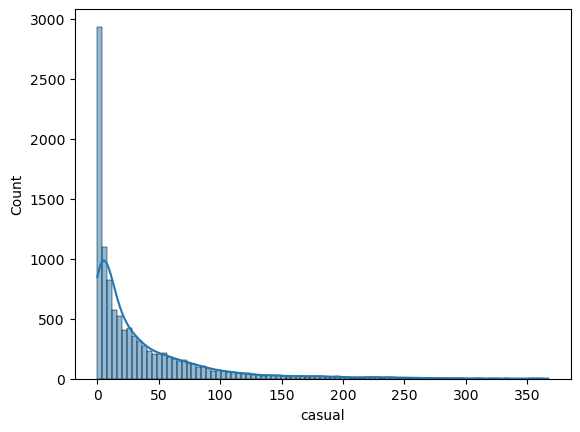

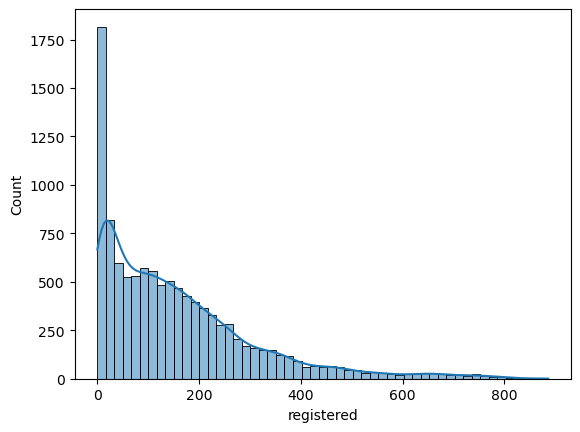

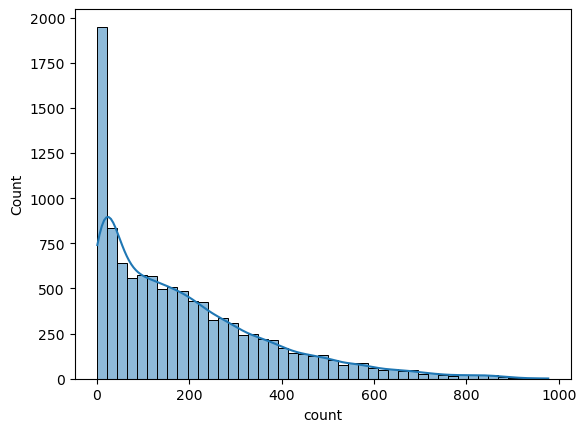

In [37]:
# Get the distribution of Numerical columns
numerical_columns = ["temp", "atemp", "humidity", "windspeed", "casual", "registered", "count"]
for col in numerical_columns:
    sns.histplot(x=col, data=df, kde=True)
    plt.show()

In [61]:
# Outlier detection
for col in numerical_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low_outliers = df[col][df[col]<(q1-1.5*iqr)]
    high_outliers = df[col][df[col]>(q3+1.5*iqr)]
    print(col)
    print("Count of lower outlier ", len(low_outliers.values.tolist()))
    print("Count of high outlier ", len(high_outliers.values.tolist()))

temp
Count of lower outlier  0
Count of high outlier  0
atemp
Count of lower outlier  0
Count of high outlier  0
humidity
Count of lower outlier  22
Count of high outlier  0
windspeed
Count of lower outlier  0
Count of high outlier  227
casual
Count of lower outlier  0
Count of high outlier  749
registered
Count of lower outlier  0
Count of high outlier  423
count
Count of lower outlier  0
Count of high outlier  300


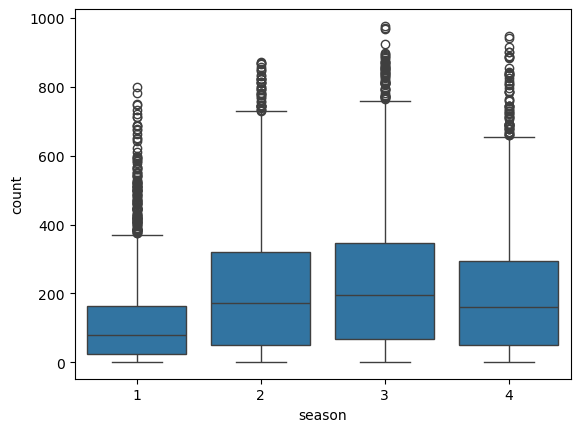

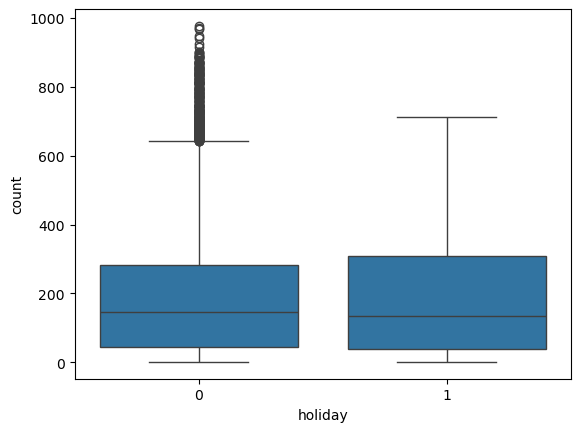

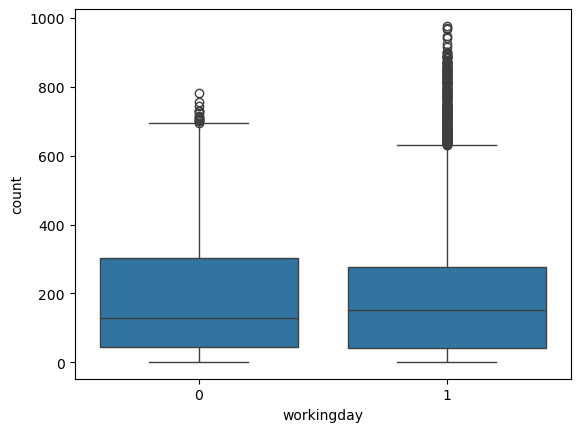

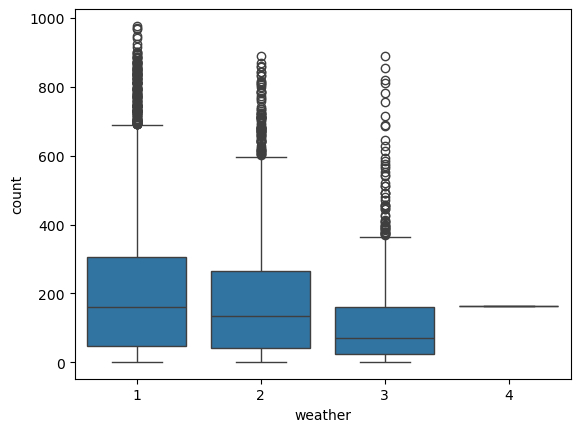

In [63]:
# Bivaritate analysis
# Create boxplots
for col in categorical_columns:
    sns.boxplot(x=col, data=df, y="count")
    plt.show()

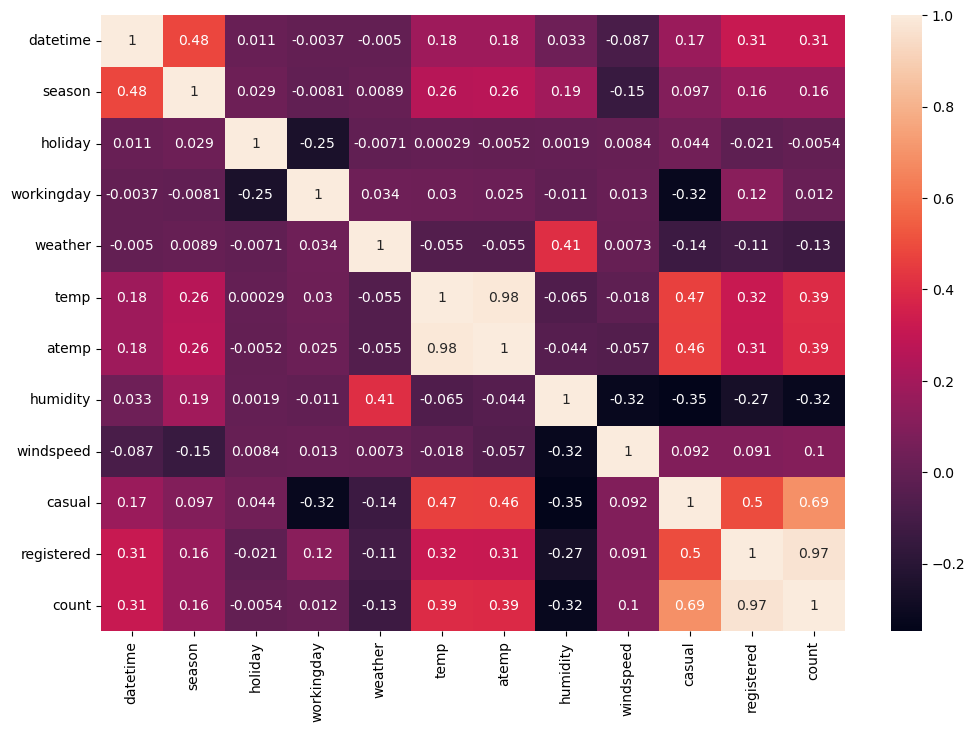

In [75]:
# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [ ]:
from scipy.stats import ttest_ind , ttest_rel , f_oneway , kruskal
from scipy.stats import norm , chi2 , f
from scipy.stats import chi2_contingency , chisquare
from scipy.stats import pearsonr , spearmanr
from scipy.stats import kstest

In [83]:
# Create weekday and weekends df to understand weekends and weekdays
weekday = df[df["workingday"]==1]
weekend = df[df["workingday"]==0]

In [87]:
# Perform the test of Normality using Shapiro-Wilk test
print("Weekday")
test_state, p_value = stats.shapiro(weekday["count"])
print(p_value)
print("Weekend")
test_state, p_value = stats.shapiro(weekend["count"])
print(p_value)

Weekday
2.2521124830019574e-61
Weekend
4.4728547627911074e-45


/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7412.
  res = hypotest_fun_out(*samples, **kwds)


In [77]:
# Hypothesis testing
# Weekday vs Weekend bike rides
# Null (H0) = Mean of 'count' is equal on Weekdays and Weekends
# Alternative (HA) = Mean of 'count' not equal on Weekdays and Weekends
stats.ttest_ind(weekday["count"], weekend["count"])

TtestResult(statistic=1.2096277376026694, pvalue=0.22644804226361348, df=10884.0)

In [79]:
# Weekday vs Weekend bike rides
# Null (H0) = Mean of 'count' is equal on Weekdays and Weekends
# Alternative (HA) = Mean of 'count' is less on Weekdays and Weekends
stats.ttest_ind(weekday["count"], weekend["count"], alternative="less")

TtestResult(statistic=1.2096277376026694, pvalue=0.8867759788681933, df=10884.0)

In [81]:
# Weekday vs Weekend bike rides
# Null (H0) = Mean of 'count' is equal on Weekdays and Weekends
# Alternative (HA) = Mean of 'count' is greater on Weekdays and Weekends
stats.ttest_ind(weekday["count"], weekend["count"], alternative="greater")

TtestResult(statistic=1.2096277376026694, pvalue=0.11322402113180674, df=10884.0)

In [91]:
# Test of equal variance - Lavene's test
stats.levene(weekday["count"], weekend["count"])

LeveneResult(statistic=0.004972848886504472, pvalue=0.9437823280916695)

In [93]:
# Understanding weather and count
weather_1 = df[df["weather"]==1]
weather_2 = df[df["weather"]==2]
weather_3 = df[df["weather"]==3]
weather_4 = df[df["weather"]==4]

In [97]:
# Perform the test of Normality using Shapiro-Wilk test
print("Weather 1")
test_state, p_value = stats.shapiro(weather_1["count"])
print(p_value)
print("Weather 2")
test_state, p_value = stats.shapiro(weather_2["count"])
print(p_value)
print("Weather 3")
test_state, p_value = stats.shapiro(weather_3["count"])
print(p_value)

Weather 1
1.5964921477006555e-57
Weather 2
9.777839106111785e-43
Weather 3
3.875893017396149e-33


/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7192.
  res = hypotest_fun_out(*samples, **kwds)


In [103]:
# Kurtosis of weathers
print(weather_1["count"].kurt())
print(weather_2["count"].kurt())
print(weather_3["count"].kurt())
print(weather_4["count"].kurt())

0.964719852310354
1.5884304891319174
6.003053730759276
nan


In [105]:
# Skew of weathers
print(weather_1["count"].skew())
print(weather_2["count"].skew())
print(weather_3["count"].skew())
print(weather_4["count"].skew())

1.1398572666918205
1.294444423357868
2.1871371080456594
nan


In [109]:
# Season and weather 
# H0 = The weather conditions are same for different seasons
# HA - The weather conditions are different for different seasons
# Chi squared test
cross_weather_season = pd.crosstab(index=df["weather"],
                                  columns=df["season"],
                                  values=df["count"],
                                  aggfunc=np.sum)
cross_weather_season

/var/folders/v3/pbt11cgx48b92xhbwckg3qsr0000gn/T/ipykernel_1725/299453412.py:5: FutureWarning: The provided callable <function sum at 0x10e303e20> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  cross_weather_season = pd.crosstab(index=df["weather"],


season,1,2,3,4
weather,,,,
1,223009,426350,470116,356588
2,76406,134177,139386,157191
3,12919,27755,31160,30255
4,164,0,0,0


In [111]:
stats.chi2_contingency(cross_weather_season)

Chi2ContingencyResult(statistic=11769.559450959445, pvalue=0.0, dof=9, expected_freq=array([[2.21180553e+05, 4.16375587e+05, 4.53449224e+05, 3.85057636e+05],
       [7.59953534e+04, 1.43062351e+05, 1.55800469e+05, 1.32301826e+05],
       [1.52975188e+04, 2.87978002e+04, 3.13619255e+04, 2.66317555e+04],
       [2.45745681e+01, 4.62619795e+01, 5.03810967e+01, 4.27823557e+01]]))